In [1]:
import numpy as np
import cv2
import os
from glob import glob
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model

In [2]:
import zipfile
import os

def unzip_into_segmentation_folder(zip_file, destination_folder):
  with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    for file_info in zip_ref.infolist():
      zip_ref.extract(file_info, destination_folder)


zip_file = '/content/segmentation.zip'  # Specify the path to your zip file
destination_folder = '/content/Segmentation'  # Specify the destination folder

# Create destination folder if it doesn't exist
if not os.path.exists(destination_folder):
  os.makedirs(destination_folder)

# Unzip all files into the segmentation folder
unzip_into_segmentation_folder(zip_file, destination_folder)

In [5]:
H = 256
W = 256

def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def load_dataset(path, split=0.3):
    images = sorted(glob(os.path.join(path, "seg_images", "*.jpg")))
    masks = sorted(glob(os.path.join(path, "seg_masks", "*.jpg")))

    if len(images) == 0 or len(masks) == 0:
        raise ValueError("No images or masks found in the specified path.")

    if len(images) != len(masks):
        raise ValueError("Number of images and masks do not match.")

    train_x, test_x, train_y, test_y = train_test_split(images, masks, test_size=split, random_state=42)

    return (train_x, train_y), (test_x, test_y)

def read_image(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.resize(x, (W, H))
    x = x / 255.0
    x = x.astype(np.float32)
    return x

def read_mask(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  ## (h, w)
    x = cv2.resize(x, (W, H))   ## (h, w)
    x = x / 255.0               ## (h, w)
    x = x.astype(np.float32)    ## (h, w)
    x = np.expand_dims(x, axis=-1)## (h, w, 1)
    return x

def tf_parse(x, y):
    def _parse(x, y):
        x = read_image(x)
        y = read_mask(y)
        return x, y

    x, y = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32])
    x.set_shape([H, W, 3])
    y.set_shape([H, W, 1])
    return x, y

def tf_dataset(X, Y, batch=2):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.map(tf_parse)
    dataset = dataset.batch(batch)
    dataset = dataset.prefetch(10)
    return dataset


np.random.seed(42)
tf.random.set_seed(42)

""" Directory for storing files """
create_dir("files")

""" Hyperparameters """
batch_size = 16
lr = 1e-4
num_epochs = 100
model_path = os.path.join("files", "model.h5")
csv_path = os.path.join("files", "log.csv")

""" Dataset """
dataset_path = '/content/segmentation'
(train_x, train_y), (test_x, test_y) = load_dataset(dataset_path)

print(f"Train: {len(train_x)} - {len(train_y)}")
print(f"Test : {len(test_x)} - {len(test_y)}")

train_dataset = tf_dataset(train_x, train_y, batch=batch_size)
valid_dataset = tf_dataset(test_x, test_y, batch=batch_size)


Train: 49 - 49
Test : 21 - 21


In [6]:
# Define the model architecture
def create_model():
    inputs = tf.keras.Input(shape=(H, W, 3))

    # Encoder
    conv1 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bottleneck
    conv4 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)

    # Decoder
    up5 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv4)
    up5 = tf.keras.layers.concatenate([up5, conv3], axis=3)
    conv5 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(up5)
    conv5 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv5)

    up6 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv5)
    up6 = tf.keras.layers.concatenate([up6, conv2], axis=3)
    conv6 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up6)
    conv6 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv6)

    up7 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv6)
    up7 = tf.keras.layers.concatenate([up7, conv1], axis=3)
    conv7 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(up7)
    conv7 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(conv7)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(conv7)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

# Define custom loss function (Dice coefficient)
def dice_coeff(y_true, y_pred):
    smooth = 1e-15
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

# Define callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path, verbose=1, save_best_only=True)
csv_logger = tf.keras.callbacks.CSVLogger(csv_path)

# Create and compile the model
model = create_model()
model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=bce_dice_loss, metrics=[dice_coeff])

# Train the model
history = model.fit(train_dataset,
                    epochs=num_epochs,
                    validation_data=valid_dataset,
                    callbacks=[checkpoint, csv_logger])

# Evaluate the model
model.evaluate(valid_dataset)

# Save history
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join("files", "history.csv"), index=False)


Epoch 1/3
4/4 [==============================] - ETA: 0s - loss: 1.6778 - dice_coeff: 0.0194 
Epoch 1: val_loss improved from inf to 1.65713, saving model to files/model.h5
4/4 [==============================] - 108s 25s/step - loss: 1.6778 - dice_coeff: 0.0194 - val_loss: 1.6571 - val_dice_coeff: 0.0211
Epoch 2/3
4/4 [==============================] - ETA: 0s - loss: 1.6511 - dice_coeff: 0.0194 
Epoch 2: val_loss improved from 1.65713 to 1.63639, saving model to files/model.h5
4/4 [==============================] - 107s 26s/step - loss: 1.6511 - dice_coeff: 0.0194 - val_loss: 1.6364 - val_dice_coeff: 0.0210
Epoch 3/3
4/4 [==============================] - ETA: 0s - loss: 1.6300 - dice_coeff: 0.0194 
Epoch 3: val_loss improved from 1.63639 to 1.61358, saving model to files/model.h5
2/2 [==============================] - 11s 3s/step - loss: 1.6136 - dice_coeff: 0.0210


1/1 [==============================] - 0s 405ms/step


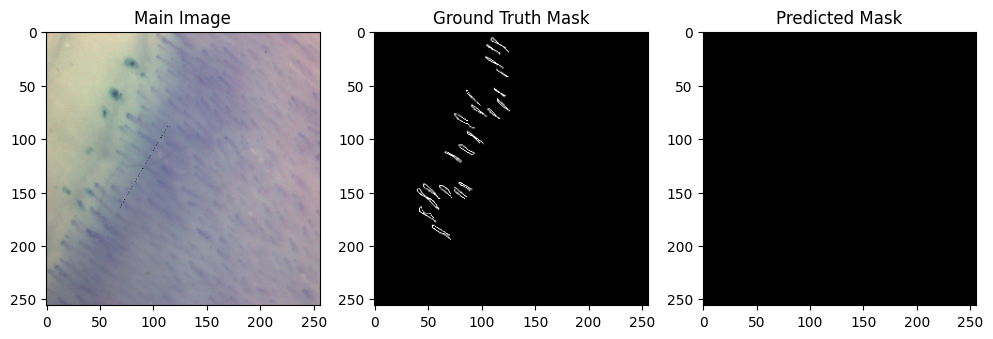

In [9]:
import matplotlib.pyplot as plt
def read_image(path):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.resize(x, (W, H))
    x = x / 255.0
    x = x.astype(np.float32)
    return x
def read_mask(path):
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  ## (h, w)
    x = cv2.resize(x, (W, H))   ## (h, w)
    x = x / 255.0
    x = x.astype(np.float32)
    x = np.expand_dims(x, axis=-1)
    return x


# Function to make predictions on new images
def predict_and_visualize(model, image_path, mask_path=None):
    # Read the image
    image = read_image(image_path)
    image = np.expand_dims(image, axis=0)

    # Predict the mask
    predicted_mask = model.predict(image)[0]

    # Threshold the mask
    predicted_mask[predicted_mask >= 0.5] = 1
    predicted_mask[predicted_mask < 0.5] = 0

    # Visualize the main image and the predicted mask
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(image[0])
    plt.title('Main Image')

    if mask_path:
        # Read the ground truth mask
        mask = read_mask(mask_path)
        plt.subplot(1, 3, 2)
        plt.imshow(mask[:, :, 0], cmap='gray')
        plt.title('Ground Truth Mask')

    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask[:, :, 0], cmap='gray')
    plt.title('Predicted Mask')

    plt.show()

# Example usage
image_path = '/content/segmentation/seg_images/N22a.jpg'
mask_path = '/content/segmentation/seg_masks/N22amask.jpg'

predict_and_visualize(model, image_path, mask_path)
